In [12]:
import os
os.getcwd()


'e:\\MonHocTrenTruong\\DataMining\\EV_Mining\\notebooks'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải dữ liệu
df = pd.read_csv('../dataset/Electric_Vehicle_Population_Data.csv')

print("--- Thông tin ban đầu về DataFrame ---")
df.info()

# --- 1.1. Làm sạch Dữ liệu, Xử lý Missing, Duplicates ---

# a) Xử lý Duplicates (Giá trị trùng lặp)
num_duplicates = df.duplicated().sum()
print(f"\nSố lượng bản ghi trùng lặp: {num_duplicates}")

if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("-> Đã loại bỏ các bản ghi trùng lặp.")
    print(f"Kích thước DataFrame sau khi loại bỏ trùng lặp: {df.shape}")

# b) Xử lý Missing Values (Giá trị thiếu)
print("\n--- Tỷ lệ Missing Values trên mỗi cột ---")
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)
missing_ratio = (missing_info / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_info, 'Missing Ratio (%)': missing_ratio})
print(missing_df)

# Xử lý: Anh nhận thấy cột 'Base MSRP' và 'Legislative District' có tỷ lệ thiếu rất cao (trên 60%).
# Đây là các cột có thể không cần thiết cho phân tích cơ bản hoặc Feature Engineering hiện tại.
# Tạm thời, anh sẽ giữ lại.

# Đối với các cột chứa thông tin vị trí ('County', 'City', 'Electric Utility', '2020 Census Tract'):
# Ta không thể điền bừa các giá trị này. Tùy thuộc vào đồ án, ta có thể:
# 1. Loại bỏ các dòng có 'County', 'City' bị thiếu (Tỷ lệ thiếu rất nhỏ).
# 2. Thay thế giá trị thiếu bằng 'Unknown' cho các cột phân loại như 'Electric Utility'.

# Xử lý Missing cho các cột quan trọng (tỷ lệ thiếu ít):
df.dropna(subset=['County', 'City'], inplace=True)
print("-> Đã loại bỏ các dòng có giá trị thiếu ở 'County' hoặc 'City'.")

# Xử lý Missing cho các cột khác (thay bằng 'Unknown' hoặc 0):
df['Electric Utility'] = df['Electric Utility'].fillna('Unknown')
df['2020 Census Tract'] = df['2020 Census Tract'].fillna('Unknown')
df['Base MSRP'] = df['Base MSRP'].fillna(df.groupby('Make')['Base MSRP'].transform('median'))
print("\nSố lượng Missing Values còn lại:")
print(df.isnull().sum().sort_values(ascending=False).head())

# --- 1.2. Chuẩn hóa Kiểu Dữ liệu ---

# Chuẩn hóa kiểu dữ liệu dựa trên df.info() ban đầu
# '2020 Census Tract' nên là kiểu Object hoặc Int (nếu đã xử lý Missing bằng -1).
# 'Electric Range' và 'Base MSRP' đã là số, nhưng nên đảm bảo là kiểu số nguyên (int/float)

print("\n--- Kiểu dữ liệu (Dtype) trước chuẩn hóa ---")
print(df.dtypes)

# Chuyển các cột về kiểu dữ liệu phù hợp:
# 'Model Year' nên là số nguyên
df['Model Year'] = df['Model Year'].astype(int)
df['Electric Range'] = df['Electric Range'].fillna(0).astype(int)

# --- Xử lý Electric Range an toàn (thay cho fillna(0)) ---

df['Electric Range'] = pd.to_numeric(df['Electric Range'], errors='coerce')

# Median theo từng loại EV
bev_median = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle']['Electric Range'].median()
phev_median = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle']['Electric Range'].median()

df.loc[
    (df['Electric Vehicle Type'] == 'Battery Electric Vehicle') &
    (df['Electric Range'].isna()),
    'Electric Range'
] = bev_median

df.loc[
    (df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle') &
    (df['Electric Range'].isna()),
    'Electric Range'
] = phev_median

# Trường hợp còn lại → 0
df['Electric Range'] = df['Electric Range'].fillna(0).astype(int)

# 'DOL Vehicle ID' là ID, nên chuyển sang object để tránh bị hiểu nhầm là giá trị số
df['DOL Vehicle ID'] = df['DOL Vehicle ID'].astype(str)
# '2020 Census Tract' là mã địa lý, chuyển sang chuỗi (string)
df['2020 Census Tract'] = df['2020 Census Tract'].astype(str)

string_cols = df.select_dtypes(include='object').columns
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip().str.upper())

print("\n--- Kiểu dữ liệu (Dtype) sau chuẩn hóa ---")
print(df.dtypes)
print(f"Kích thước DataFrame sau tiền xử lý: {df.shape}")

--- Thông tin ban đầu về DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264628 entries, 0 to 264627
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         264628 non-null  object 
 1   County                                             264619 non-null  object 
 2   City                                               264619 non-null  object 
 3   State                                              264628 non-null  object 
 4   Postal Code                                        264619 non-null  float64
 5   Model Year                                         264628 non-null  int64  
 6   Make                                               264628 non-null  object 
 7   Model                                              264628 non-null  object 
 8   Electric Vehicle Type              


--- Phân bố theo Loại Xe Điện (Electric Vehicle Type) ---
Electric Vehicle Type
BATTERY ELECTRIC VEHICLE (BEV)            210568
PLUG-IN HYBRID ELECTRIC VEHICLE (PHEV)     54051
Name: count, dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_15576\73363825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_type_counts.index, y=ev_type_counts.values, palette="viridis")


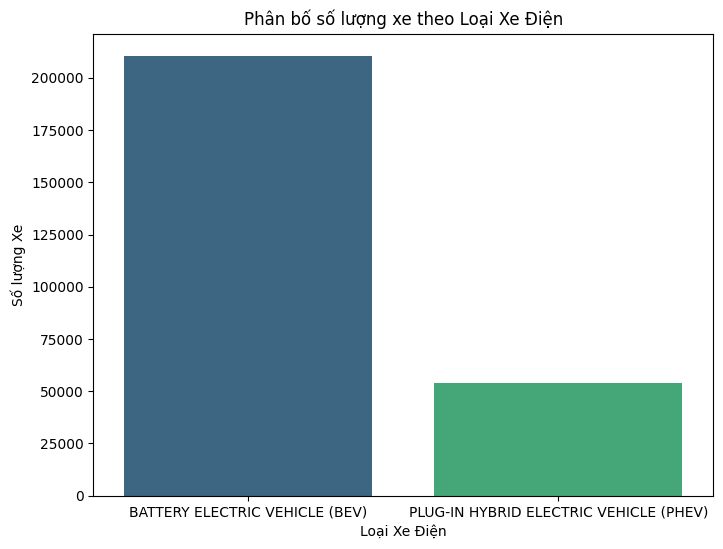


--- Phân bố Xe theo Năm Sản Xuất (Model Year) ---
Model Year
2017     8667
2018    14322
2019    10935
2020    12213
2021    20772
2022    29397
2023    60156
2024    49234
2025    32674
2026     7047
Name: count, dtype: int64


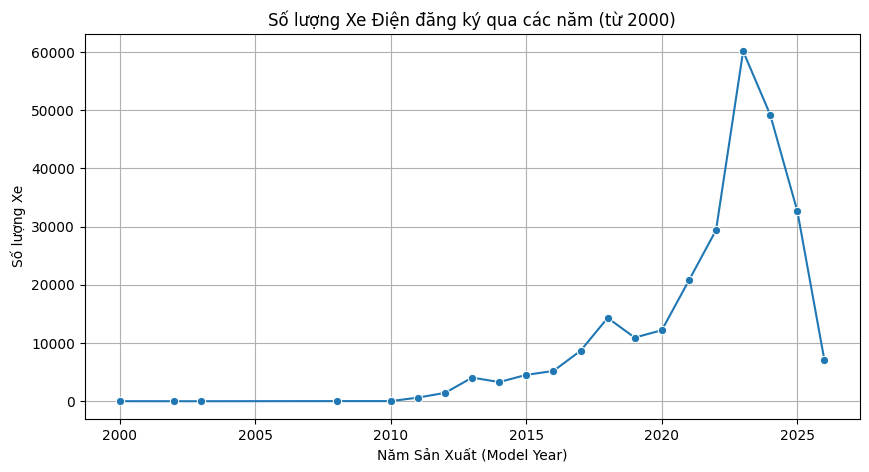


--- Top 10 Hãng Xe Điện (Make) ---
Make
TESLA         108628
CHEVROLET      19051
NISSAN         16177
FORD           14346
KIA            13183
TOYOTA         11022
BMW            10882
HYUNDAI         9278
RIVIAN          8118
VOLKSWAGEN      7073
Name: count, dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_15576\73363825.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_counts.index, y=make_counts.values, palette="rocket")


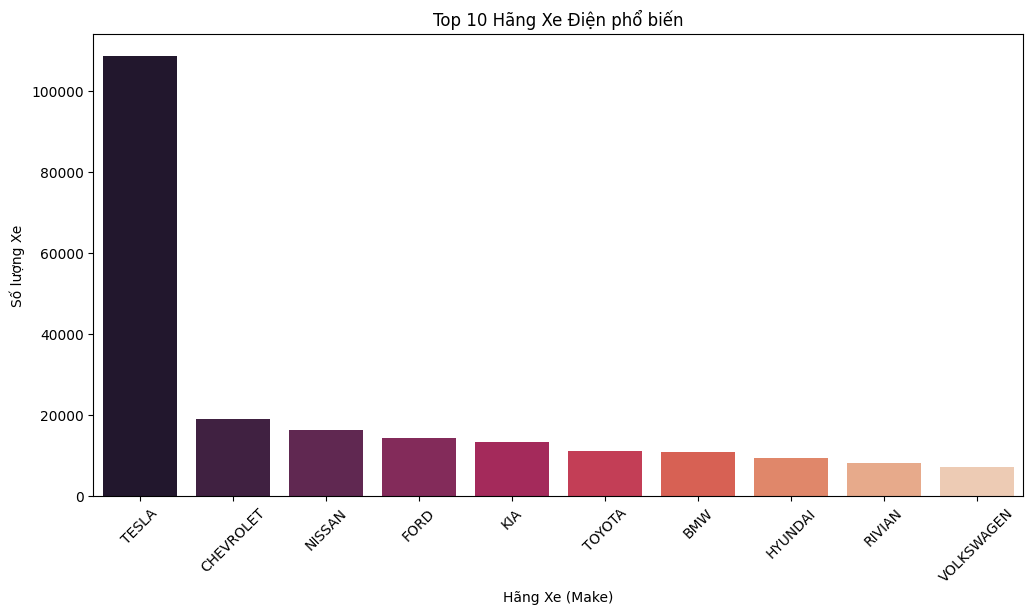


--- Thống kê mô tả về Phạm vi Điện (Electric Range) ---
count    264619.000000
mean         41.712224
std          80.377379
min           0.000000
25%           0.000000
50%           0.000000
75%          34.000000
max         337.000000
Name: Electric Range, dtype: float64


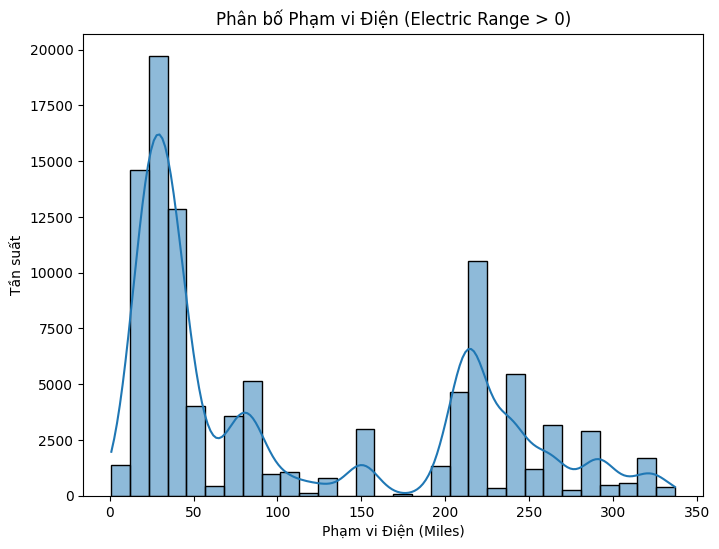

In [14]:
# --- 2. EDA: Phân tích Phân bố ---

# a) Phân bố theo 'Electric Vehicle Type'
print("\n--- Phân bố theo Loại Xe Điện (Electric Vehicle Type) ---")
ev_type_counts = df['Electric Vehicle Type'].value_counts()
print(ev_type_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=ev_type_counts.index, y=ev_type_counts.values, palette="viridis")
plt.title('Phân bố số lượng xe theo Loại Xe Điện')
plt.xlabel('Loại Xe Điện')
plt.ylabel('Số lượng Xe')
plt.xticks(rotation=0)
plt.show()
# 

# b) Phân bố 'Model Year'
print("\n--- Phân bố Xe theo Năm Sản Xuất (Model Year) ---")
# Chỉ xem các năm từ 2000 trở đi để tập trung vào dữ liệu hiện đại
year_counts = df[df['Model Year'] >= 2000]['Model Year'].value_counts().sort_index()
print(year_counts.tail(10)) # In 10 năm gần nhất

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Số lượng Xe Điện đăng ký qua các năm (từ 2000)')
plt.xlabel('Năm Sản Xuất (Model Year)')
plt.ylabel('Số lượng Xe')
plt.grid(True)
plt.show()
# 

# c) Top 10 Hãng Xe ('Make')
print("\n--- Top 10 Hãng Xe Điện (Make) ---")
make_counts = df['Make'].value_counts().head(10)
print(make_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=make_counts.index, y=make_counts.values, palette="rocket")
plt.title('Top 10 Hãng Xe Điện phổ biến')
plt.xlabel('Hãng Xe (Make)')
plt.ylabel('Số lượng Xe')
plt.xticks(rotation=45)
plt.show()
# 

# d) Phân tích 'Electric Range'
print("\n--- Thống kê mô tả về Phạm vi Điện (Electric Range) ---")
print(df['Electric Range'].describe())

plt.figure(figsize=(8, 6))
# Chỉ vẽ Histogram cho Range > 0 để dễ quan sát hơn
sns.histplot(df[df['Electric Range'] > 0]['Electric Range'], bins=30, kde=True)
plt.title('Phân bố Phạm vi Điện (Electric Range > 0)')
plt.xlabel('Phạm vi Điện (Miles)')
plt.ylabel('Tần suất')
plt.show()
#

In [15]:
# --- 3. Feature Engineering ---

# a) Tạo EV_Count theo Year ('EVs_by_Year')
# Đặc trưng này cho biết tổng số lượng xe điện của một Model Year cụ thể trong dataset.

ev_count_by_year = df.groupby('Model Year').size().reset_index(name='EVs_by_Year')
# Merge đặc trưng mới vào DataFrame gốc
df = pd.merge(df, ev_count_by_year, on='Model Year', how='left')

print("\n--- Top 5 dòng đầu tiên với đặc trưng 'EVs_by_Year' mới ---")
print(df[['Model Year', 'EVs_by_Year']].head())

# b) Tạo EV_Count theo State/City ('EVs_by_City')
# Đặc trưng này cho biết tổng số lượng xe điện trong một thành phố cụ thể.
# Lưu ý: State ở đây hầu như là WA (Washington) theo dữ liệu gốc, nên City là yếu tố chính.

ev_count_by_city = df.groupby(['State', 'City']).size().reset_index(name='EVs_by_City')
# Merge đặc trưng mới vào DataFrame gốc
df = pd.merge(df, ev_count_by_city, on=['State', 'City'], how='left')

print("\n--- Top 5 dòng đầu tiên với đặc trưng 'EVs_by_City' mới ---")
print(df[['State', 'City', 'EVs_by_City']].head())

# c) [BONUS] Tạo Đặc trưng Phân loại CAFV (Clean Alternative Fuel Vehicle)
# Chia 'Clean Alternative Fuel Vehicle (CAFV) Eligibility' thành một đặc trưng nhị phân (0/1)
# 1 nếu Eligible, 0 nếu Not Eligible/Unknown.

df['Is_CAFV_Eligible'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(
    lambda x: 1 if ('ELIGIBLE' in x and 'NOT' not in x) else 0
)

print("\n--- Top 5 dòng đầu tiên với đặc trưng nhị phân 'Is_CAFV_Eligible' ---")
print(df[['Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Is_CAFV_Eligible']].head())

# --- Kết quả cuối cùng ---
print("\n--- Thông tin DataFrame sau khi Feature Engineering ---")
df.info()
print("\nTop 5 dòng cuối cùng của DataFrame đã xử lý:")
print(df.tail(5))


--- Top 5 dòng đầu tiên với đặc trưng 'EVs_by_Year' mới ---
   Model Year  EVs_by_Year
0        2024        49234
1        2018        14322
2        2015         4532
3        2019        10935
4        2022        29397

--- Top 5 dòng đầu tiên với đặc trưng 'EVs_by_City' mới ---
  State     City  EVs_by_City
0    WA  OLYMPIA         6212
1    WA   WAPATO           36
2    WA  SEATTLE        41533
3    WA     KENT         4483
4    WA  BOTHELL         8721

--- Top 5 dòng đầu tiên với đặc trưng nhị phân 'Is_CAFV_Eligible' ---
   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Is_CAFV_Eligible
0              NOT ELIGIBLE DUE TO LOW BATTERY RANGE                 0
1              NOT ELIGIBLE DUE TO LOW BATTERY RANGE                 0
2            CLEAN ALTERNATIVE FUEL VEHICLE ELIGIBLE                 1
3            CLEAN ALTERNATIVE FUEL VEHICLE ELIGIBLE                 1
4  ELIGIBILITY UNKNOWN AS BATTERY RANGE HAS NOT B...                 0

--- Thông tin DataFrame sau khi Featur